In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os 

user_profile =os.environ.get('user_profile','C:\\Users\\ZAID AWAN')
file_path=os.path.join(user_profile,'Desktop','pakistan_petroleum_sales_practice.csv')

try:
    df=pd.read_csv(file_path)
    print(f"raw dataa set successfully loaded:{df.shape[0]} rows,{df.shape[1]} columns.")

except FileNotFoundError :
    df=pd.read_csv('pakistan_petroleum_sales_practice.csv')
    print(f"dataset loaded successfull:{df.shape[0]} row,df{df.shape[1]} columns.")

    print("\nFirst 5 rows of raw data")
    df.head(6)

raw dataa set successfully loaded:5068 rows,12 columns.


In [2]:
print("cheking for missing values in column:")
print(df.isnull().sum())

print("checking payment method as unique")
print(df['Payment_Method'].unique())

print("describing fuel price pkr per liter")
df['Price_Per_Liter_PKR'].describe()

cheking for missing values in column:
Transaction_ID           0
Date                     0
Station_Name             0
OMC                      0
City                     0
Province                 0
Fuel_Type                0
Price_Per_Liter_PKR     50
Volume_Sold_Liters     103
Total_Revenue_PKR      392
Payment_Method         106
Customer_Type           48
dtype: int64
checking payment method as unique
<StringArray>
[         'cash',   'credit card',   'Credit Card',          'Cash',
      'JazzCash',          'CASH',    'Fleet Card',    'Debit Card',
             nan, 'Mobile Wallet',     'EasyPaisa']
Length: 11, dtype: str
describing fuel price pkr per liter


count    5018.000000
mean      395.753643
std      1110.041999
min       -99.000000
25%       229.995000
50%       280.910000
75%       300.745000
max      9999.000000
Name: Price_Per_Liter_PKR, dtype: float64

In [3]:
df_clean=df.drop_duplicates(subset=['Transaction_ID']).copy()
print(f"duplicates: Removed {df.shape[0] - df_clean.shape[0]}  duplicates records")


duplicates: Removed 68  duplicates records


In [4]:
df_clean['Date']=pd.to_datetime(df_clean['Date'],errors='coerce',format='mixed')
unparseable_date=df_clean['Date'].isnull().sum()
df_clean =df_clean.dropna(subset=['Date'])
print(f"standardized date :standard:dropped{unparseable_date} rows with unparseable date")

df_clean['Payment_Method'] = df_clean['Payment_Method'].astype(str).str.strip().str.upper()
payment_map={
    'CASH':'Cash',
    'CREDIT CARD':'Credit Card',
    'DEBIT CARD':'Debit Card',
    'MOBILE WALLET':'Mobile Wallet',
    'EASYPAISE':'Mobile Wallet',
    'JAZZCASH':'Mobile Wallet',
    'FLEET CARD':'Fleet Card',
    'NAN':'Unknown',
    '':'Unknown'
}
df_clean['Payment_Method']=df_clean['Payment_Method'].map(lambda x:payment_map.get(x,'Unknown'))
df_clean['Customer_Type']=df_clean['Customer_Type'].str.strip().str.capitalize()

df_clean['Customer_Type']=df_clean['Customer_Type'].replace({
    'Nan':'Unknown',
    '':'Unknown'
})



standardized date :standard:dropped0 rows with unparseable date


In [5]:
medians_by_fuel=(
    df_clean.groupby('Fuel_Type')['Price_Per_Liter_PKR']
    
    .median()
)
def clean_fuel_price(row):
    p=row['Price_Per_Liter_PKR']
    if pd.isnull(p) or p<200 or p>350 :
        return medians_by_fuel.get(row['Fuel_Type'],275.0)
    return p
df_clean['Price_Per_Liter_PKR']=df_clean.apply(clean_fuel_price,axis=1)
print("input extreme price outlier wih fuel_type Medians")

input extreme price outlier wih fuel_type Medians


In [6]:
median_vol = df_clean[df_clean['Volume_Sold_Liters']>0]['Volume_Sold_Liters'].median()
df_clean['Volume_Sold_Liters']=df_clean['Volume_Sold_Liters'].fillna(median_vol)
df_clean.loc[df_clean['Volume_Sold_Liters']<=0,'Volume_Sold_Liters']=median_vol
print("volume cooreection")


volume cooreection


In [7]:
df_clean['Total_Revenue_PKR']=round(df_clean['Price_Per_Liter_PKR']*df_clean['Volume_Sold_Liters'],2)
PROFIT_MARGIN=0.08
df_clean['Profit_PKR']=round(df_clean['Total_Revenue_PKR']*PROFIT_MARGIN,2)

df_clean['Month_Year']=df_clean['Date'].dt.to_period('M')
print("calculated net profite")

calculated net profite


In [8]:
district_summary=df_clean.groupby('City').agg(
    Total_Volume_Sold_Liters=('Volume_Sold_Liters','sum'),
    Total_Revenue=('Total_Revenue_PKR','sum'),
    Total_Profit_PKR=('Profit_PKR','sum'),
    Active_Stations=('Station_Name','nunique'),
).sort_values(by='Total_Profit_PKR',ascending=False).reset_index()


print("District city performance summary:")
display(district_summary.style.format({
    'Total_Volume_Sold_Liters':'{:,.2f}',
    'Total_Revenue':'{:,.2f}',
    'Total_Profit_PKR':'{:,.2f}',
    'Active_Stations':'{:,}'
}))

District city performance summary:


,City,Total_Volume_Sold_Liters,Total_Revenue,Total_Profit_PKR,Active_Stations
0,Karachi,"451,947.72","123,611,360.34","9,888,908.65",25
1,Lahore,"435,097.34","121,349,779.08","9,707,982.40",25
2,Rawalpindi,"426,044.57","115,762,848.15","9,261,027.90",25
3,Islamabad,"416,961.60","113,867,091.73","9,109,367.42",25
4,Multan,"391,752.16","109,122,126.32","8,729,770.27",25
5,Peshawar,"392,379.07","105,381,714.53","8,430,537.21",25
6,Quetta,"355,520.22","96,105,035.01","7,688,402.89",25
7,Sialkot,"358,866.23","94,478,027.18","7,558,242.09",25
8,Faisalabad,"274,309.54","73,580,293.31","5,886,423.62",25


In [9]:
monthly_summary = df_clean.groupby('Month_Year').agg(
    Total_Volume_Sold_Liters=('Volume_Sold_Liters', 'sum'),
    Total_Revenue_PKR=('Total_Revenue_PKR', 'sum'),
    Total_Profit_PKR=('Profit_PKR', 'sum'),
    Average_Fuel_Price_PKR=('Price_Per_Liter_PKR', 'mean')
).reset_index()

# Convert period back to string to show correctly in standard formatting
monthly_summary['Month_Year'] = monthly_summary['Month_Year'].astype(str)

print("📅 MONTH-BY-MONTH SALES & FINANCIAL TREND:")
display(monthly_summary.style.format({
    'Total_Volume_Sold_Liters': '{:,.2f}',
    'Total_Revenue_PKR': 'Rs. {:,.2f}',
    'Total_Profit_PKR': 'Rs. {:,.2f}',
    'Average_Fuel_Price_PKR': 'Rs. {:.2f}'
}))

📅 MONTH-BY-MONTH SALES & FINANCIAL TREND:


,Month_Year,Total_Volume_Sold_Liters,Total_Revenue_PKR,Total_Profit_PKR,Average_Fuel_Price_PKR
0,2025-01,"197,153.97","Rs. 54,099,745.39","Rs. 4,327,979.61",Rs. 271.04
1,2025-02,"146,300.51","Rs. 38,098,480.92","Rs. 3,047,878.57",Rs. 273.79
2,2025-03,"235,619.49","Rs. 66,105,241.13","Rs. 5,288,419.30",Rs. 268.97
3,2025-04,"120,415.73","Rs. 31,281,975.37","Rs. 2,502,558.05",Rs. 267.81
4,2025-05,"166,654.33","Rs. 44,380,311.86","Rs. 3,550,425.03",Rs. 269.54
5,2025-06,"247,355.33","Rs. 67,035,874.75","Rs. 5,362,869.98",Rs. 275.42
6,2025-07,"115,504.97","Rs. 31,907,085.77","Rs. 2,552,566.90",Rs. 272.60
7,2025-08,"241,577.06","Rs. 63,790,647.71","Rs. 5,103,251.82",Rs. 271.73
8,2025-09,"192,233.85","Rs. 53,677,007.27","Rs. 4,294,160.58",Rs. 274.29
9,2025-10,"160,282.46","Rs. 44,722,223.84","Rs. 3,577,777.92",Rs. 269.19


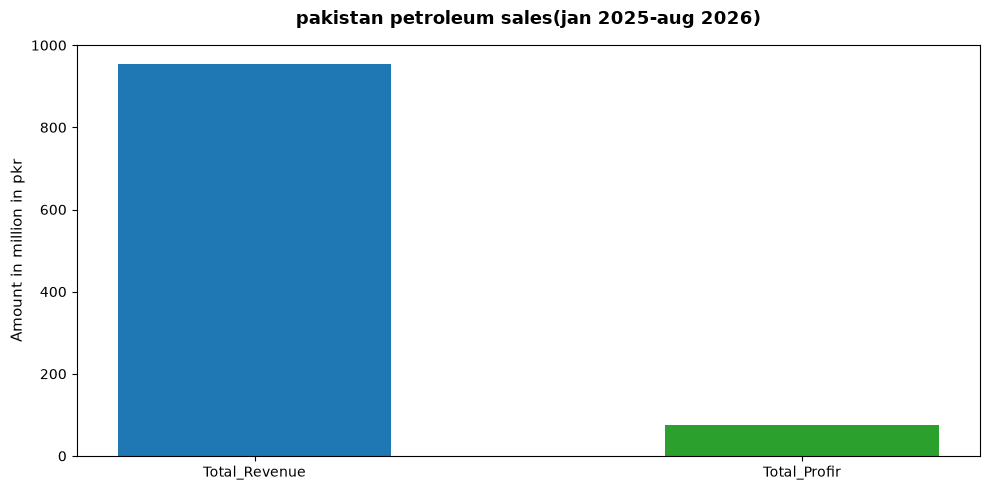

In [10]:
plt.figure(figsize=(10,5))
total_profit=df_clean['Profit_PKR'].sum()/1e6
total_revenue=df_clean['Total_Revenue_PKR'].sum()/1e6

bars =plt.bar(['Total_Revenue','Total_Profir'],[total_revenue,total_profit],color=['#1f77b4','#2ca02c'],width=0.5)
plt.title("pakistan petroleum sales(jan 2025-aug 2026)",fontsize=13,fontweight='bold',pad=15)
plt.ylabel('Amount in million in pkr',fontsize=11)


plt.tight_layout()
plt.show()


C:\Users\ZAID AWAN\AppData\Local\Temp\ipykernel_5276\1129249213.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=district_summary, x='City', y='Total_Profit_PKR', palette='Blues_r')
findfont: Failed to find font weight semibold, now using 700.


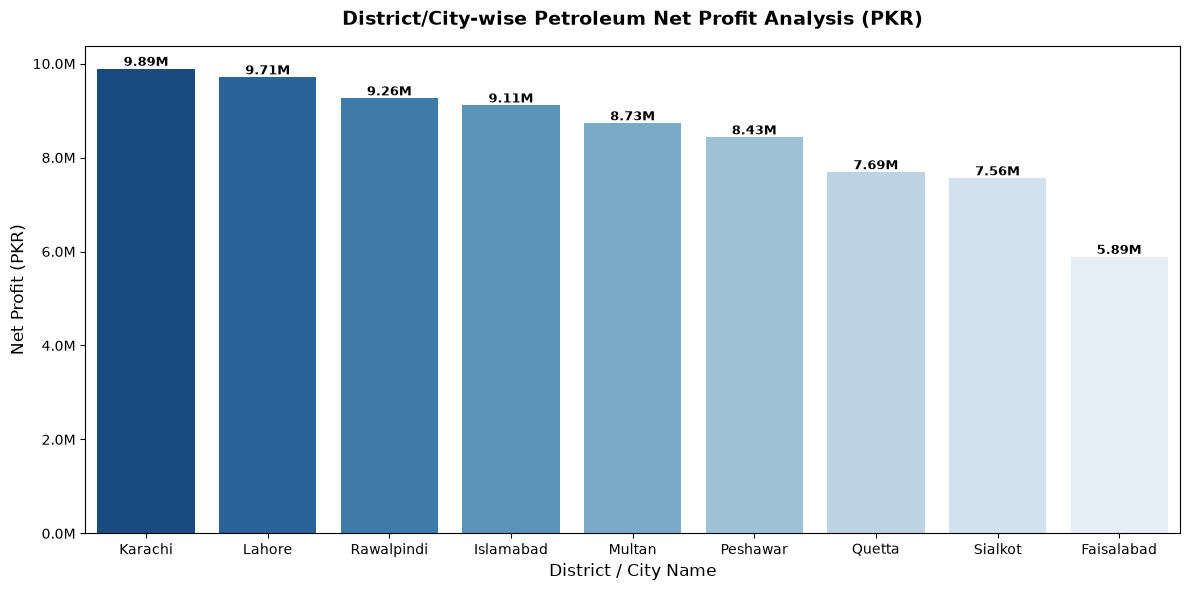

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(data=district_summary, x='City', y='Total_Profit_PKR', palette='Blues_r')
plt.title('District/City-wise Petroleum Net Profit Analysis (PKR)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('District / City Name', fontsize=12)
plt.ylabel('Net Profit (PKR)', fontsize=12)

# Format Y-axis to display in Millions 'M'
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*1e-6:.1f}M'))

# Display numeric labels on top of bars
for index, row in district_summary.iterrows():
    plt.text(index, row['Total_Profit_PKR'], f"{row['Total_Profit_PKR']*1e-6:.2f}M", 
             color='black', ha="center", va="bottom", fontsize=9, fontweight='semibold')

plt.tight_layout()
plt.show()

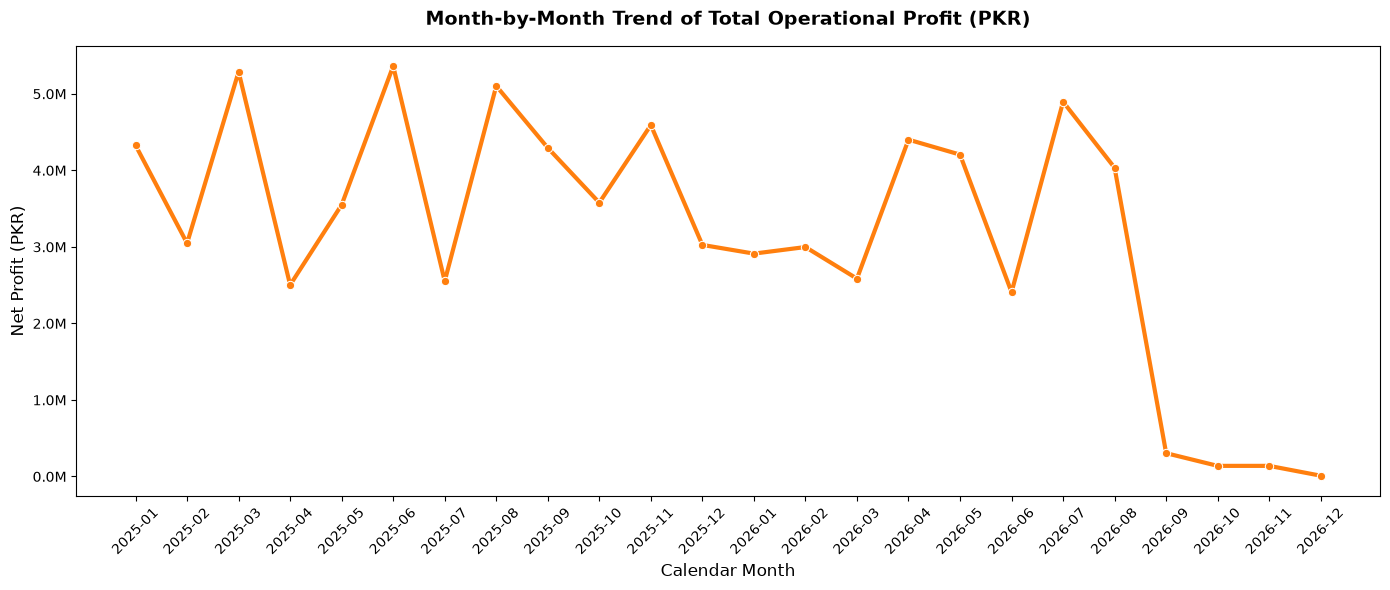

In [12]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_summary, x='Month_Year', y='Total_Profit_PKR', marker='o', color='#ff7f0e', linewidth=3)
plt.title('Month-by-Month Trend of Total Operational Profit (PKR)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Calendar Month', fontsize=12)
plt.ylabel('Net Profit (PKR)', fontsize=12)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*1e-6:.1f}M'))

plt.tight_layout()
plt.show()

C:\Users\ZAID AWAN\AppData\Local\Temp\ipykernel_5276\2640182018.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(monthly_summary['Month_Year'], rotation=45)
C:\Users\ZAID AWAN\AppData\Local\Temp\ipykernel_5276\2640182018.py:27: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
c:\Users\ZAID AWAN\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


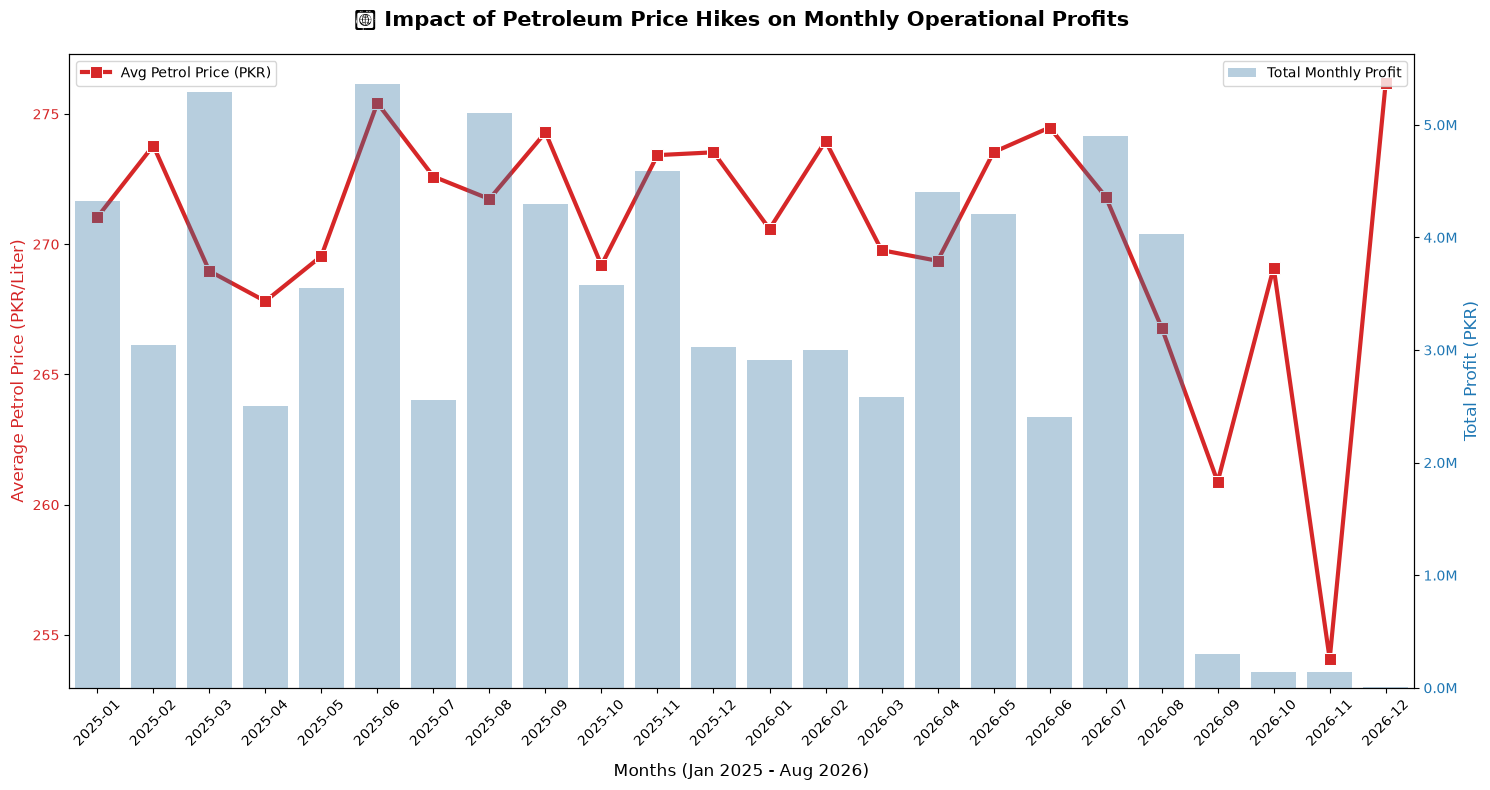

In [13]:
fig, ax1 = plt.subplots(figsize=(15, 8))

# Left axis: Average Fuel Price Trend (Line Plot)
color_price = '#d62728'
ax1.set_xlabel('Months (Jan 2025 - Aug 2026)', fontsize=12, labelpad=10)
ax1.set_ylabel('Average Petrol Price (PKR/Liter)', color=color_price, fontsize=12)

sns.lineplot(data=monthly_summary, x='Month_Year', y='Average_Fuel_Price_PKR', ax=ax1, 
             marker='s', markersize=8, color=color_price, linewidth=3, label='Avg Petrol Price (PKR)')
ax1.tick_params(axis='y', labelcolor=color_price)
ax1.set_xticklabels(monthly_summary['Month_Year'], rotation=45)
ax1.legend(loc='upper left')
ax1.grid(False) # Turn off left axis grid to prevent line clutter

# Right axis: Total Monthly Profit (Bar Plot Overlay)
ax2 = ax1.twinx()
color_profit = '#1f77b4'
ax2.set_ylabel('Total Profit (PKR)', color=color_profit, fontsize=12)

sns.barplot(data=monthly_summary, x='Month_Year', y='Total_Profit_PKR', ax=ax2, 
            alpha=0.35, color=color_profit, label='Total Monthly Profit')
ax2.tick_params(axis='y', labelcolor=color_profit)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*1e-6:.1f}M'))
ax2.legend(loc='upper right')

plt.title('🔍 Impact of Petroleum Price Hikes on Monthly Operational Profits', fontsize=15, fontweight='bold', pad=20)
fig.tight_layout()
plt.show()